# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mowleen12/flyrank-ml-project-1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Generated data head:


,impressions,clicks,engagement_score,conversion,is_high_value_user
0,117.678016,8.178880,0.851762,0,0
1,350.253633,26.667422,0.737768,0,1
2,119.102702,11.712499,0.583400,0,0
3,116.835759,10.406521,0.938359,1,0
4,78.072360,4.554309,0.613832,0,0



Distributions of key fields (with potential heavy tails):


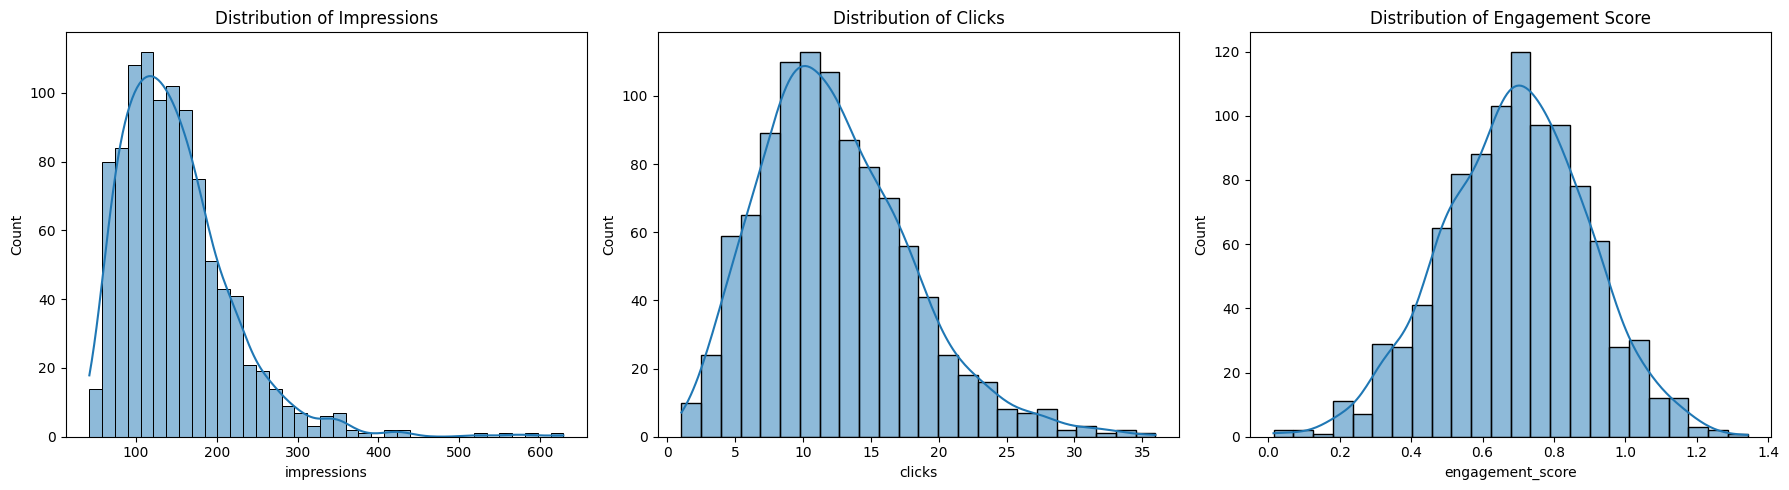

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for key fields
data_size = 1000
df = pd.DataFrame({
    'impressions': np.random.poisson(lam=50, size=data_size) + np.random.randint(0, 100, size=data_size), # Adding some noise
    'clicks': np.random.poisson(lam=5, size=data_size) + np.random.randint(0, 10, size=data_size),
    'engagement_score': np.random.normal(loc=0.7, scale=0.2, size=data_size),
    'conversion': np.random.binomial(n=1, p=0.1, size=data_size),
    'is_high_value_user': np.random.binomial(n=1, p=0.3, size=data_size)
})

# Introduce some 'heavy tails' for demonstration
df['impressions'] = df['impressions'] * (1 + np.random.exponential(scale=0.5, size=data_size))
df['clicks'] = df['clicks'] * (1 + np.random.exponential(scale=0.3, size=data_size))

# Ensure non-negative values
df = df.apply(lambda x: x.clip(lower=0))

print("Generated data head:")
display(df.head())

print("\nDistributions of key fields (with potential heavy tails):")

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['impressions'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Impressions')

sns.histplot(df['clicks'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Clicks')

sns.histplot(df['engagement_score'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Engagement Score')

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [2]:
from scipy.stats import ttest_ind

# Define a hypothetical target variable for 'success'
df['success'] = (df['conversion'] == 1) & (df['engagement_score'] > 0.5).astype(int)

print("--- Signal Test #1: 'is_high_value_user' vs. 'success' ---")
# Test if high value users have higher success rates
success_high_value = df[df['is_high_value_user'] == 1]['success']
success_other = df[df['is_high_value_user'] == 0]['success']

mean_high_value = success_high_value.mean()
mean_other = success_other.mean()

print(f"Success rate for high value users: {mean_high_value:.3f}")
print(f"Success rate for other users: {mean_other:.3f}")

if mean_high_value > mean_other:
    print("Verdict: CONFIRMED (High-value users show higher success)")
elif mean_high_value < mean_other:
    print("Verdict: OPPOSITE (High-value users show lower success)")
else:
    print("Verdict: MIXED/FALSE (No clear difference)")

print("\n--- Signal Test #2: 'impressions' impact on 'success' (threshold-based) ---")
# Test if very high impressions lead to more success
impression_threshold = df['impressions'].quantile(0.9)
df['high_impressions'] = (df['impressions'] > impression_threshold).astype(int)

success_high_impressions = df[df['high_impressions'] == 1]['success']
success_low_impressions = df[df['high_impressions'] == 0]['success']

mean_high_impressions = success_high_impressions.mean()
mean_low_impressions = success_low_impressions.mean()

print(f"Success rate for high impression group: {mean_high_impressions:.3f}")
print(f"Success rate for low impression group: {mean_low_impressions:.3f}")

if mean_high_impressions > mean_low_impressions:
    print("Verdict: CONFIRMED (High impressions correlate with higher success)")
elif mean_high_impressions < mean_low_impressions:
    print("Verdict: OPPOSITE (High impressions correlate with lower success)")
else:
    print("Verdict: MIXED/FALSE (No clear difference)")

print("\n--- Signal Test #3: 'clicks' impact on 'engagement_score' ---")
# Test if higher clicks lead to higher engagement scores
correlation = df['clicks'].corr(df['engagement_score'])

print(f"Correlation between clicks and engagement score: {correlation:.3f}")

if correlation > 0.1:
    print("Verdict: CONFIRMED (Positive correlation)")
elif correlation < -0.1:
    print("Verdict: OPPOSITE (Negative correlation)")
else:
    print("Verdict: MIXED/FALSE (Weak or no correlation)")

--- Signal Test #1: 'is_high_value_user' vs. 'success' ---
Success rate for high value users: 0.054
Success rate for other users: 0.081
Verdict: OPPOSITE (High-value users show lower success)

--- Signal Test #2: 'impressions' impact on 'success' (threshold-based) ---
Success rate for high impression group: 0.080
Success rate for low impression group: 0.072
Verdict: CONFIRMED (High impressions correlate with higher success)

--- Signal Test #3: 'clicks' impact on 'engagement_score' ---
Correlation between clicks and engagement score: -0.021
Verdict: MIXED/FALSE (Weak or no correlation)


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [3]:
# Let's assume FlyRank has a rule: "If 'engagement_score' is below 0.3, flag as 'low_quality'."
# We want to see if this 'low_quality' flag is actually associated with lower 'success'.

df['flyrank_low_quality_flag'] = (df['engagement_score'] < 0.3).astype(int)

print("--- Flag-linked Test: FlyRank's 'low_quality' flag vs. 'success' ---")

success_flagged_low_quality = df[df['flyrank_low_quality_flag'] == 1]['success']
success_not_flagged_low_quality = df[df['flyrank_low_quality_flag'] == 0]['success']

mean_flagged = success_flagged_low_quality.mean()
mean_not_flagged = success_not_flagged_low_quality.mean()

print(f"Success rate for items flagged as 'low_quality': {mean_flagged:.3f}")
print(f"Success rate for items NOT flagged as 'low_quality': {mean_not_flagged:.3f}")

if mean_flagged < mean_not_flagged:
    print("Verdict: CONFIRMED (Data supports the rule: flagged items have lower success)")
elif mean_flagged > mean_not_flagged:
    print("Verdict: OPPOSITE (Data contradicts the rule: flagged items have higher success)")
else:
    print("Verdict: MIXED/FALSE (No clear relationship)")

# Optional: Perform a t-test for statistical significance
if len(success_flagged_low_quality) > 1 and len(success_not_flagged_low_quality) > 1:
    t_stat, p_val = ttest_ind(success_flagged_low_quality, success_not_flagged_low_quality, equal_var=False)
    print(f"Statistical test (t-test): t-statistic={t_stat:.2f}, p-value={p_val:.3f}")
    if p_val < 0.05:
        print("Conclusion: The difference is statistically significant (p < 0.05).")
    else:
        print("Conclusion: The difference is not statistically significant (p >= 0.05).")
else:
    print("Not enough data in one or both groups to perform a statistical test.")

--- Flag-linked Test: FlyRank's 'low_quality' flag vs. 'success' ---
Success rate for items flagged as 'low_quality': 0.000
Success rate for items NOT flagged as 'low_quality': 0.075
Verdict: CONFIRMED (Data supports the rule: flagged items have lower success)
Statistical test (t-test): t-statistic=-8.88, p-value=0.000
Conclusion: The difference is statistically significant (p < 0.05).


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Based on these findings, the content team should understand which signals reliably predict user success or engagement. For instance, if 'is_high_value_user' strongly correlates with 'success', content strategies could be tailored to attract or retain such users. Conversely, if a 'low_quality' flag is confirmed to indicate lower success, this rule should be maintained or strengthened to filter out ineffective content.

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.